In [12]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from utils.data_loader import load_parquet, load_csv

# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

GFOC_data_old = load_csv(columns=columns_needed)
print(GFOC_data_old.head())

# for statistics
df = pd.read_parquet("Dataset/Dataset_MSc/GFOC_RDCDFI.parquet")
cols = df.columns


old_cols = pd.read_csv("Dataset/Dataset_MSc/GFOC_RDCDFI.csv", nrows=0).columns


✅ Successfully loaded data with shape: (3157920, 2)
                 time  orbital_decay
0 2023-01-01 00:00:00        16.6730
1 2023-01-01 00:00:20        16.6730
2 2023-01-01 00:00:40        16.6735
3 2023-01-01 00:01:00        16.6740
4 2023-01-01 00:01:20        16.6740
✅ Successfully loaded data with shape: (1486079, 3)
   index                time  orbital_decay
0      0 2023-01-02 12:00:00       9.269174
1      1 2023-01-02 12:00:30       9.316983
2      2 2023-01-02 12:01:00       9.352912
3      3 2023-01-02 12:01:30       9.384055
4      4 2023-01-02 12:02:00       9.426476


In [13]:
print(cols)
print(old_cols)

Index(['a_m', 'aDot_m_s', 'orbital_decay', 'SVN', 'X_IN [m]', 'Y_IN [m]',
       'Z_IN [m]', 'VX_IN [m/s]', 'VY_IN [m/s]', 'VZ_IN [m/s]',
       ...
       'Electric Field (Mv/m)_res', 'Proton density (n/cc)_res_std',
       'Proton density (n/cc)_slope', 'Proton density (n/cc)_intercept',
       'Proton density (n/cc)_se_slope', 'Proton density (n/cc)_res',
       'F10.7 (LASP)', 'F30 (LASP)', 'Kp (LASP)', 'ap (LASP)'],
      dtype='object', length=126)
Index(['time', 'SVN', 'X_IN [m]', 'Y_IN [m]', 'Z_IN [m]', 'VX_IN [m/s]',
       'VY_IN [m/s]', 'VZ_IN [m/s]', 'X_EF [m]', 'Y_EF [m]',
       ...
       'res_std_c', 'unresolved_c', 'mean_altitude_c', 'trend_c', 'residual_c',
       'seasonal_1_c', 'seasonal_2_c', 'seasonal_3_c', 'seasonal_4_c',
       'se_orbital_decay_c'],
      dtype='object', length=117)


In [15]:
# save to txt file with newline separation
with open("GFOC_old_columns.txt", "w") as f:
    for col in old_cols:
        f.write(col + "\n")

In [18]:
# compare column names
common_cols = set(cols).intersection(set(old_cols))
print(f"Common columns ({len(common_cols)}): {common_cols}")
unique_to_new = set(cols) - set(old_cols)
print(f"Columns unique to new dataset ({len(unique_to_new)}): {unique_to_new}")
unique_to_old = set(old_cols) - set(cols)
print(f"Columns unique to old dataset ({len(unique_to_old)}): {unique_to_old}")

# save to txt file with newline separation
with open("GFOC_columns_analysis.txt", "w") as f:
    f.write("Common columns:\n")
    for col in common_cols:
        f.write(col + "\n")
    f.write("\nColumns unique to new dataset:\n")
    for col in unique_to_new:
        f.write(col + "\n")
    f.write("\nColumns unique to old dataset:\n")
    for col in unique_to_old:
        f.write(col + "\n")

Common columns (77): {'lat_ell [deg]', 'beta_sun [deg]', 'VX_EF [m/s]', 'Bz GSE', 'X_IN [m]', 'Magnetosonic mach number', 'RMS Timeshift (seconds)', 'VX_IN [m/s]', 'F10.7 (LASP)', 'Alfven mach number', 'Plasma beta', 'VY_IN [m/s]', '|avg B|', 'r [m]', 'orbital_decay', 'Spacecraft Position z', 'Bx GSE', 'Flow pressure (nPa)', '# fine scale Plasma points', 'Vy Velocity (km/s)', 'Proton density (n/cc)', 'a [m]', 'Omega [deg]', 'Time between observations (seconds)', 'V [m^2/s^2]', 'Z_IN [m]', 'SymD (Omni)', 'h_ell [m]', 'omega [deg]', 'Approximate Distance to SEL (Re)', 'i [deg]', 'Spacecraft Position x', 'Vx Velocity (km/s)', 'Z_EF [m]', 'ae (Omni)', 'lon_ell [deg]', 'Kp (LASP)', 'Au (Omni)', 'Bow Shock Nose Position z', 'VZ_EF [m/s]', 'Bz GSM', 'X_EF [m]', 'T0 [s]', 'By GSM', 'Bow Shock Nose Position x', 'a [m] TLE', 'u_sat [deg]', 'Temperature (K)', 'Alpha/Proton Ratio', 'rho [kg/m^3]', 'RMS SD B scalar (nT)', 'Bow Shock Nose Position y', 'Vz Velocity (km/s)', 'ap (LASP)', 'Spacecraft I

## Statistics

In [ ]:
# Time range for both datasets
print("---GFOC_data---")
print("time range:", GFOC_data['time'].min(), "to", GFOC_data['time'].max())
print("No. parameters:", len(cols))  # There is no time column to exclude
print("\n---GFOC_data_old---")
print("time range:", GFOC_data_old['time'].min(), "to", GFOC_data_old['time'].max())
print("No. parameters:", len(old_cols) - 1)  # Exclude time column from count

---GFOC_data---
time range: 2023-01-01 00:00:00 to 2024-12-31 23:59:00
No. parameters: 126

---GFOC_data_old---
time range: 2023-01-02 12:00:00 to 2024-06-30 11:59:30
No. parameters: 116


## Plots

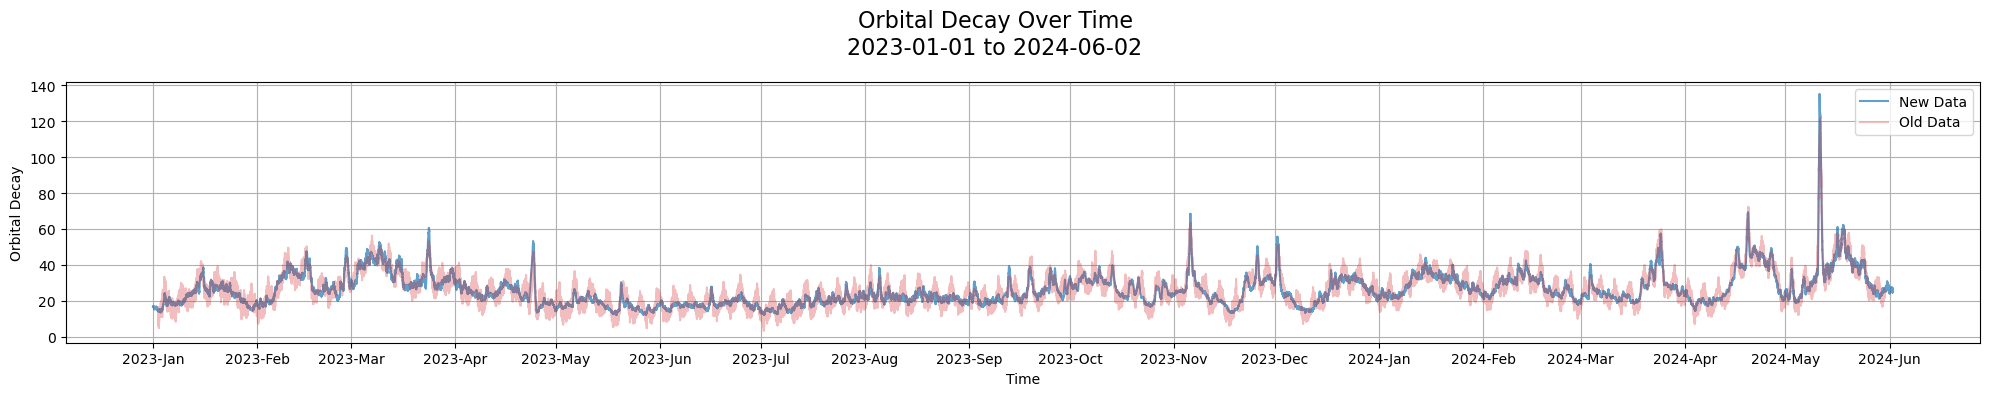

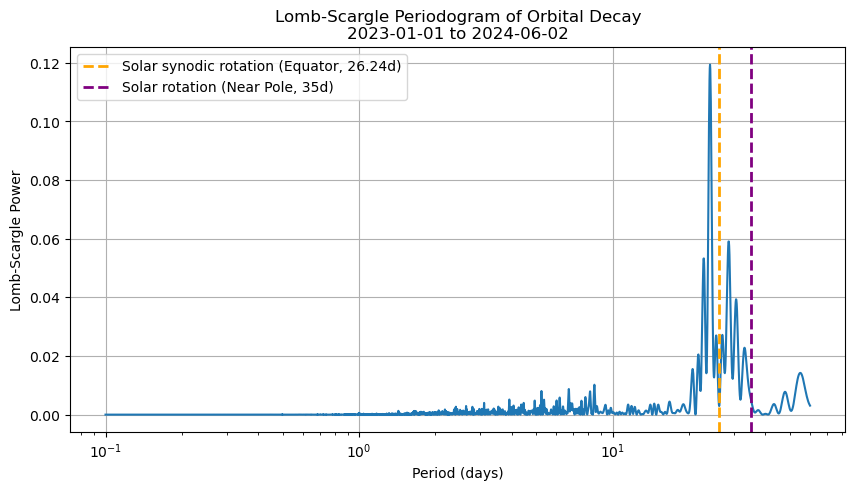

Strongest period: 24.20 days


In [22]:
from utils.plot_loader import plot_orbital_decay, plot_lombscargle_periodogram

# =========================== Input ===================================
start_date = '2023-01-01 00:00:00'
end_date = '2024-06-02 00:00:00'

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'monthly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 1  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

Flags = False

plot_orbital_decay(GFOC_data, GFOC_data_old, start_date, end_date, tick_interval, tick_step, FLAGS=Flags, Lombscargle=True, figsize=(20, 4))
# plot_lombscargle_periodogram(GFOC_data, start_date, end_date, 0.01, 0.5, vlines= False, print_period='minutes')
# plot_lombscargle_periodogram(GFOC_data, start_date, end_date, 0.01, 40, vlines= True, print_period='days')

# Findings

When looking at the two datasets I can clearly detect some major differences